In [1]:
import tensorflow as tf
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Load dataset
data = pd.read_csv('/kaggle/input/datasets/organizations/uciml/breast-cancer-wisconsin-data/data.csv')

# Drop unnecessary columns
data = data.drop(['id','Unnamed: 32'], axis=1)

# Encode target
data['diagnosis'] = data['diagnosis'].map({'M':0,'B':1})

# Features and labels
X = data.drop('diagnosis', axis=1).values
y = data['diagnosis'].values

# Preprocess
scaler = StandardScaler()
X = scaler.fit_transform(X)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

2026-03-13 14:50:55.231149: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1773413455.472678      16 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1773413455.545539      16 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1773413456.125064      16 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773413456.125117      16 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773413456.125121      16 computation_placer.cc:177] computation placer alr

X_train shape: (455, 30)
X_test shape: (114, 30)


In [2]:
!pip install pennylane pennylane-lightning

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.3/5.3 MB 66.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 935.6/935.6 kB 33.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 167.9/167.9 kB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 48.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 45.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 88.3 MB/s eta 0:00:00


# Quantum circuit

In [3]:
import pennylane as qml

n_qubits = 4
dev = qml.device("default.qubit", wires=n_qubits)

@qml.qnode(dev, interface="tf")
def quantum_circuit(inputs, weights):
    for i in range(n_qubits):
        qml.RY(inputs[i], wires=i)
    for i in range(n_qubits):
        qml.RZ(weights[i], wires=i)
    return [qml.expval(qml.PauliZ(i)) for i in range(n_qubits)]

# Quantum weights
weights = tf.Variable(tf.random.uniform([n_qubits]), dtype=tf.float32)

# Lambda layer
def quantum_layer_tf(x):
    x_slice = x[:, :n_qubits]
    res = quantum_circuit(x_slice, weights)
    res = tf.math.real(res)
    return res

qlayer = tf.keras.layers.Lambda(quantum_layer_tf)

2026-03-13 14:51:45.417347: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


# build qcnn model

In [4]:
# Safe quantum layer for batch input
def quantum_layer_tf_batch(x):
    # x shape = (batch_size, n_features)
    def single_sample(sample):
        # use first n_qubits features
        res = quantum_circuit(sample[:n_qubits], weights)
        return tf.math.real(res)
    
    # vectorize over the batch
    res = tf.vectorized_map(single_sample, x)
    return res  # shape (batch_size, n_qubits)

# Build QCNN model
input_layer = tf.keras.layers.Input(shape=(X_train.shape[1],))
dense1 = tf.keras.layers.Dense(16, activation='relu')(input_layer)
qlayer = tf.keras.layers.Lambda(quantum_layer_tf_batch)(dense1)
dense2 = tf.keras.layers.Dense(8, activation='relu')(qlayer)
output = tf.keras.layers.Dense(1, activation='sigmoid')(dense2)

model = tf.keras.Model(inputs=input_layer, outputs=output)
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.summary()

/tmp/ipykernel_16/1230957530.py:6: PennyLaneDeprecationWarning: Support for the TensorFlow interface is deprecated and will be removed in v0.44. Future versions of PennyLane are not guaranteed to work with TensorFlow. Please migrate your workflows to JAX or Pytorch to benefit from enhanced support and features.
  res = quantum_circuit(sample[:n_qubits], weights)


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 30)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambda_1 (Lambda)               │ (None, 4)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │            40 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 545 (2.13 KB)

 Trainable params: 545 (2.13 KB)

 Non-trainable params: 0 (0.00 B)

# train QCNN

In [5]:
history = model.fit(X_train, y_train, epochs=20,
                    batch_size=16, validation_split=0.1)

Epoch 1/20


/tmp/ipykernel_16/1230957530.py:6: PennyLaneDeprecationWarning: Support for the TensorFlow interface is deprecated and will be removed in v0.44. Future versions of PennyLane are not guaranteed to work with TensorFlow. Please migrate your workflows to JAX or Pytorch to benefit from enhanced support and features.
  res = quantum_circuit(sample[:n_qubits], weights)


26/26 ━━━━━━━━━━━━━━━━━━━━ 5s 45ms/step - accuracy: 0.3526 - loss: 0.8017 - val_accuracy: 0.3261 - val_loss: 0.7482
Epoch 2/20
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.3884 - loss: 0.7162 - val_accuracy: 0.6522 - val_loss: 0.6663
Epoch 3/20
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6348 - loss: 0.6637 - val_accuracy: 0.7174 - val_loss: 0.6184
Epoch 4/20
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6451 - loss: 0.6354 - val_accuracy: 0.7391 - val_loss: 0.5755
Epoch 5/20
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7260 - loss: 0.5865 - val_accuracy: 0.7826 - val_loss: 0.5229
Epoch 6/20
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8256 - loss: 0.5113 - val_accuracy: 0.8478 - val_loss: 0.4700
Epoch 7/20
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8243 - loss: 0.4828 - val_accuracy: 0.8696 - val_loss: 0.4275
Epoch 8/20
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8225 - loss: 0.4420 - val_accuracy: 0.8696 - val_loss: 0.3931
Ep

# EVALUATE QCNN

/tmp/ipykernel_16/1230957530.py:6: PennyLaneDeprecationWarning: Support for the TensorFlow interface is deprecated and will be removed in v0.44. Future versions of PennyLane are not guaranteed to work with TensorFlow. Please migrate your workflows to JAX or Pytorch to benefit from enhanced support and features.
  res = quantum_circuit(sample[:n_qubits], weights)


4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 224ms/step
 QCNN Classification Report:

              precision    recall  f1-score     support
Benign         0.976190  0.953488  0.964706   43.000000
Malignant      0.972222  0.985915  0.979021   71.000000
accuracy       0.973684  0.973684  0.973684    0.973684
macro avg      0.974206  0.969702  0.971863  114.000000
weighted avg   0.973719  0.973684  0.973621  114.000000

Test Accuracy: 0.9737


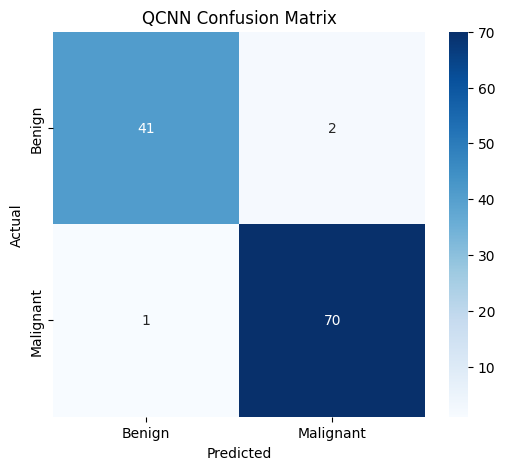

In [6]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns

# Predict on test set
y_pred = model.predict(X_test)
y_pred_classes = (y_pred > 0.5).astype(int).flatten()

target_names = ['Benign','Malignant']
report_dict = classification_report(y_test, y_pred_classes, target_names=target_names, output_dict=True)
df_report = pd.DataFrame(report_dict).transpose()
print(" QCNN Classification Report:\n")
print(df_report)

# Accuracy
acc = accuracy_score(y_test, y_pred_classes)
print(f"\nTest Accuracy: {acc:.4f}")

# Confusion matrix
cm = confusion_matrix(y_test, y_pred_classes)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=target_names, yticklabels=target_names)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("QCNN Confusion Matrix")
plt.show()

# PLOT TRAINING HISTORY

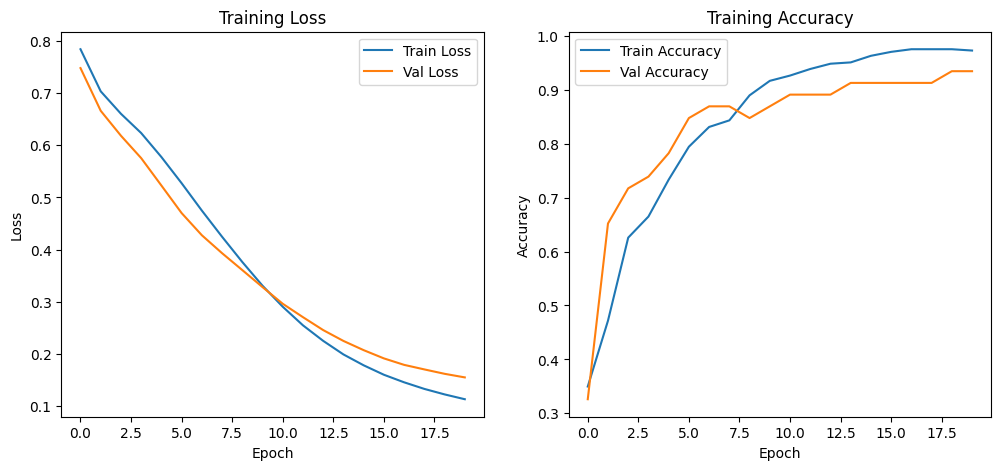

In [7]:
plt.figure(figsize=(12,5))

# Loss
plt.subplot(1,2,1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss')
plt.legend()

# Accuracy
plt.subplot(1,2,2)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training Accuracy')
plt.legend()

plt.show()

# COMPARING QCNN WITH CNN

In [8]:
cnn_model = tf.keras.Sequential([
    tf.keras.layers.Dense(16, activation='relu', input_shape=(X_train.shape[1],)),
    tf.keras.layers.Dense(8, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

cnn_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

#  Train classical CNN
cnn_history = cnn_model.fit(X_train, y_train, epochs=20, batch_size=16, validation_split=0.1, verbose=0)

# Evaluate classical CNN
y_pred_cnn = (cnn_model.predict(X_test) > 0.5).astype(int).flatten()
acc_cnn = accuracy_score(y_test, y_pred_cnn)
report_cnn = classification_report(y_test, y_pred_cnn, target_names=['Benign','Malignant'], output_dict=True)
df_report_cnn = pd.DataFrame(report_cnn).transpose()

y_pred_qcnn = (model.predict(X_test) > 0.5).astype(int).flatten()
acc_qcnn = accuracy_score(y_test, y_pred_qcnn)
report_qcnn = classification_report(y_test, y_pred_qcnn, target_names=['Benign','Malignant'], output_dict=True)
df_report_qcnn = pd.DataFrame(report_qcnn).transpose()

# Comparison table: Accuracy
comparison = pd.DataFrame({
    "Model": ["Classical NN","QCNN"],
    "Test Accuracy": [acc_cnn, acc_qcnn]
})
print(" Model Accuracy Comparison:")
print(comparison)
print("\nClassical NN Classification Report:\n", df_report_cnn)
print("\n QCNN Classification Report:\n", df_report_qcnn)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step 
 Model Accuracy Comparison:
          Model  Test Accuracy
0  Classical NN       0.964912
1          QCNN       0.973684

Classical NN Classification Report:
               precision    recall  f1-score     support
Benign         0.933333  0.976744  0.954545   43.000000
Malignant      0.985507  0.957746  0.971429   71.000000
accuracy       0.964912  0.964912  0.964912    0.964912
macro avg      0.959420  0.967245  0.962987  114.000000
weighted avg   0.965828  0.964912  0.965060  114.000000

 QCNN Classification Report:
               precision    recall  f1-score     support
Benign         0.976190  0.953488  0.964706   43.000000
Malignant      0.972222  0.985915  0.979021   71.000000
accuracy       0.973684  0.973684  0.973684    0.973684
macro avg      0.974206  0.969702  0.971863  114.000000
weighted avg   0.973719  0.973684  0.973621  114.000000
